In [1]:
from google.colab import files
import pandas as pd
import io

print("Please upload clean_data.csv from your desktop...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("File loaded!")
print("Shape:", df.shape)
df.head(3)

Please upload clean_data.csv from your desktop...


Saving clean_data.csv to clean_data.csv
File loaded!
Shape: (22628, 11)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,review_length
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,8
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,62
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,98


In [3]:
!pip install textblob -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [4]:
sample_reviews = [
    "I absolutely love this dress! Perfect fit and beautiful color.",
    "Terrible quality. Fell apart after one wash. Very disappointed.",
    "It is okay. Nothing special about it."
]

print("HOW TEXTBLOB READS SENTIMENT:")
print("=" * 50)
for review in sample_reviews:
    blob = TextBlob(review)
    score = blob.sentiment.polarity
    print(f"\nReview : {review[:55]}...")
    print(f"Score  : {round(score, 3)}")
    print(f"Meaning: {'POSITIVE' if score > 0.1 else 'NEGATIVE' if score < -0.1 else 'NEUTRAL'}")

HOW TEXTBLOB READS SENTIMENT:

Review : I absolutely love this dress! Perfect fit and beautiful...
Score  : 0.719
Meaning: POSITIVE

Review : Terrible quality. Fell apart after one wash. Very disap...
Score  : -0.988
Meaning: NEGATIVE

Review : It is okay. Nothing special about it....
Score  : 0.429
Meaning: POSITIVE


In [5]:
def get_sentiment_label(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

def get_sentiment_score(text):
    return round(TextBlob(str(text)).sentiment.polarity, 4)

print("Analyzing sentiment for all reviews...")
print("Please wait 1-2 minutes...")

df['sentiment_label'] = df['Review Text'].apply(get_sentiment_label)
df['sentiment_score'] = df['Review Text'].apply(get_sentiment_score)

print("\nDone! Sentiment breakdown:")
print(df['sentiment_label'].value_counts())

Analyzing sentiment for all reviews...
Please wait 1-2 minutes...

Done! Sentiment breakdown:
sentiment_label
positive    18666
neutral      3537
negative      425
Name: count, dtype: int64


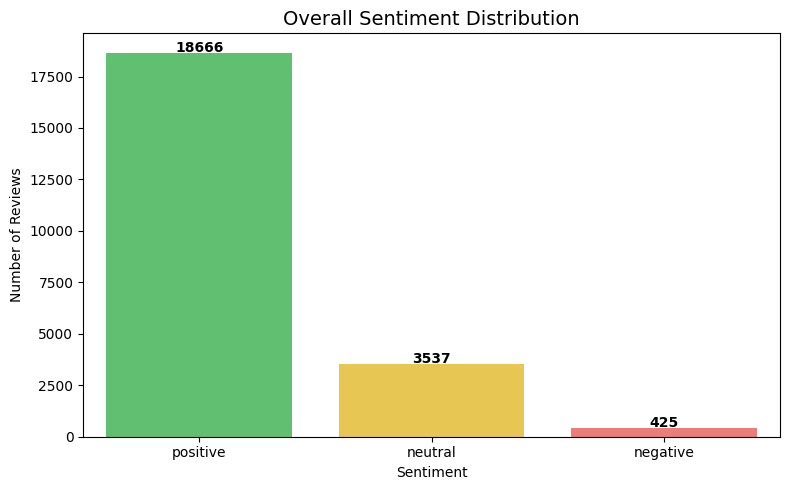

In [6]:
plt.figure(figsize=(8, 5))
sentiment_counts = df['sentiment_label'].value_counts()
colors = ['#51cf66', '#ffd43b', '#ff6b6b']

sns.barplot(x=sentiment_counts.index,
            y=sentiment_counts.values,
            palette=colors)

plt.title('Overall Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

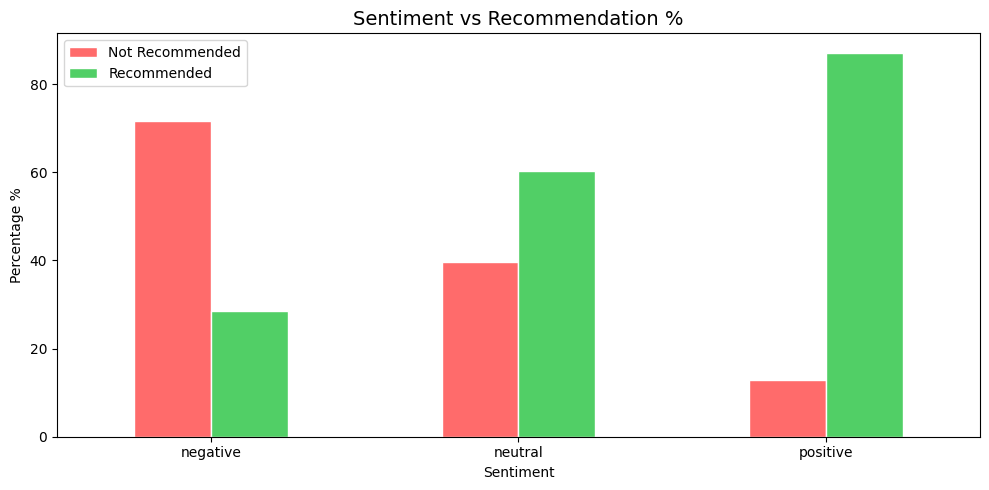


Key Insight:
Recommended IND     0     1
sentiment_label            
negative         71.5  28.5
neutral          39.6  60.4
positive         12.8  87.2


In [7]:
plt.figure(figsize=(10, 5))

cross = pd.crosstab(df['sentiment_label'],
                    df['Recommended IND'],
                    normalize='index') * 100

cross.plot(kind='bar',
           color=['#ff6b6b', '#51cf66'],
           edgecolor='white',
           figsize=(10, 5))

plt.title('Sentiment vs Recommendation %', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Percentage %')
plt.xticks(rotation=0)
plt.legend(['Not Recommended', 'Recommended'])
plt.tight_layout()
plt.show()

print("\nKey Insight:")
print(cross.round(1))

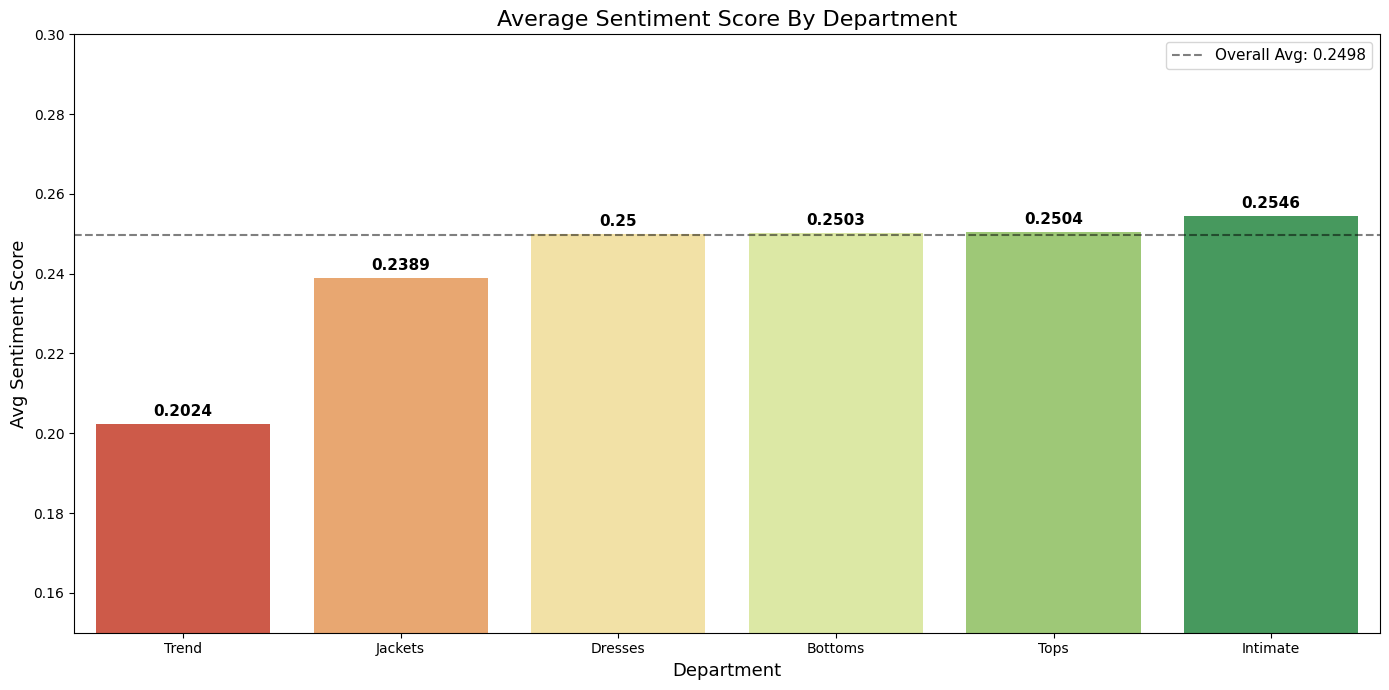


Department Sentiment Scores:
Department Name
Trend       0.2024
Jackets     0.2389
Dresses     0.2500
Bottoms     0.2503
Tops        0.2504
Intimate    0.2546
Name: sentiment_score, dtype: float64


In [9]:
plt.figure(figsize=(14, 7))

dept_sentiment = df.groupby('Department Name')['sentiment_score'].mean().sort_values()

bars = sns.barplot(x=dept_sentiment.index,
            y=dept_sentiment.values,
            palette='RdYlGn')

# Add exact score above every bar
for i, v in enumerate(dept_sentiment.values):
    plt.text(i, v + 0.002, str(round(v, 4)),
             ha='center', fontweight='bold', fontsize=11)

plt.title('Average Sentiment Score By Department', fontsize=16)
plt.xlabel('Department', fontsize=13)
plt.ylabel('Avg Sentiment Score', fontsize=13)

# Fix scale — start from 0.15 to show differences clearly
plt.ylim(0.15, 0.30)

plt.axhline(y=df['sentiment_score'].mean(),
            color='black', linestyle='--',
            alpha=0.5, label=f'Overall Avg: {round(df["sentiment_score"].mean(),4)}')

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nDepartment Sentiment Scores:")
print(dept_sentiment.round(4))

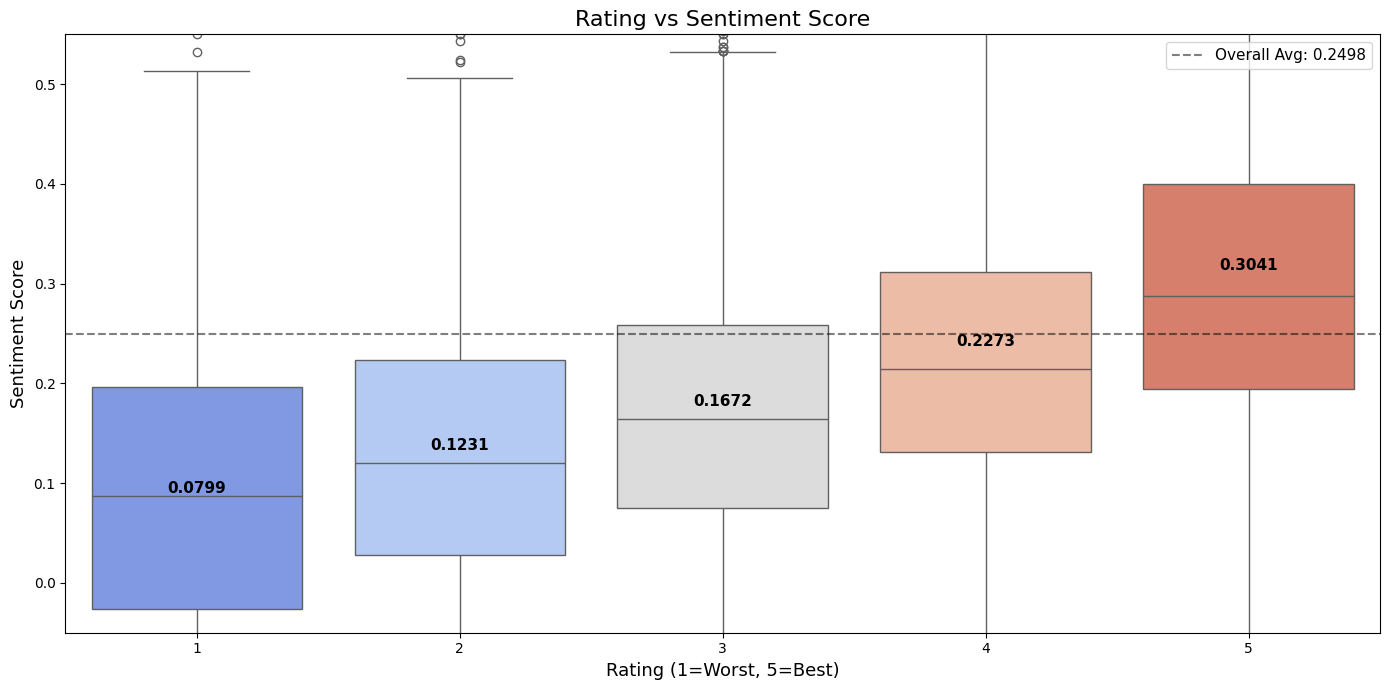


Average sentiment per rating:
Rating
1    0.0799
2    0.1231
3    0.1672
4    0.2273
5    0.3041
Name: sentiment_score, dtype: float64


In [12]:
plt.figure(figsize=(14, 7))

sns.boxplot(x='Rating',
            y='sentiment_score',
            data=df,
            palette='coolwarm')

# Add exact average score above each box
rating_means = df.groupby('Rating')['sentiment_score'].mean()
for i, (rating, mean_val) in enumerate(rating_means.items()):
    plt.text(i, mean_val + 0.01, str(round(mean_val, 4)),
             ha='center', fontweight='bold', fontsize=11,
             color='black')

plt.title('Rating vs Sentiment Score', fontsize=16)
plt.xlabel('Rating (1=Worst, 5=Best)', fontsize=13)
plt.ylabel('Sentiment Score', fontsize=13)

# Fix scale to show differences clearly
plt.ylim(-0.05, 0.55)

# Add overall average line
plt.axhline(y=df['sentiment_score'].mean(),
            color='black', linestyle='--',
            alpha=0.5, label=f'Overall Avg: {round(df["sentiment_score"].mean(),4)}')

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nAverage sentiment per rating:")
print(rating_means.round(4))

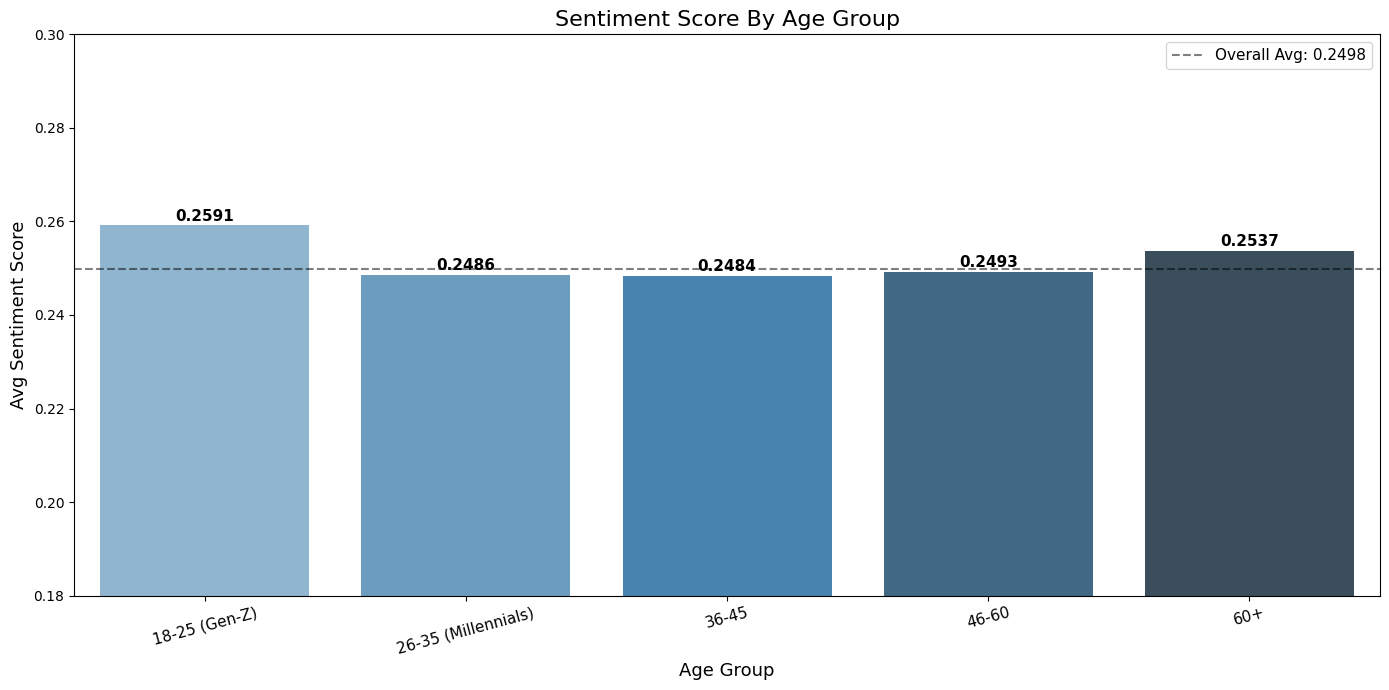


Age Group Sentiment Scores:
age_group
18-25 (Gen-Z)          0.2591
26-35 (Millennials)    0.2486
36-45                  0.2484
46-60                  0.2493
60+                    0.2537
Name: sentiment_score, dtype: float64

Gen-Z (18-25) avg sentiment: 0.2591


In [13]:
df['age_group'] = pd.cut(df['Age'],
                          bins=[0, 25, 35, 45, 60, 100],
                          labels=['18-25 (Gen-Z)',
                                  '26-35 (Millennials)',
                                  '36-45',
                                  '46-60',
                                  '60+'])

plt.figure(figsize=(14, 7))
age_sentiment = df.groupby('age_group', observed=True)['sentiment_score'].mean()

bars = sns.barplot(x=age_sentiment.index,
            y=age_sentiment.values,
            palette='Blues_d')

# Add exact score above every bar
for i, v in enumerate(age_sentiment.values):
    plt.text(i, v + 0.001, str(round(v, 4)),
             ha='center', fontweight='bold', fontsize=11)

plt.title('Sentiment Score By Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=13)
plt.ylabel('Avg Sentiment Score', fontsize=13)

# Fix scale to show differences clearly
plt.ylim(0.18, 0.30)

# Add overall average line
plt.axhline(y=df['sentiment_score'].mean(),
            color='black', linestyle='--',
            alpha=0.5, label=f'Overall Avg: {round(df["sentiment_score"].mean(),4)}')

plt.xticks(rotation=15, fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nAge Group Sentiment Scores:")
print(age_sentiment.round(4))

print(f"\nGen-Z (18-25) avg sentiment:",
      round(df[df['age_group']=='18-25 (Gen-Z)']['sentiment_score'].mean(), 4))

In [14]:
pos = len(df[df['sentiment_label']=='positive'])
neg = len(df[df['sentiment_label']=='negative'])
neu = len(df[df['sentiment_label']=='neutral'])
pos_rec = df[df['sentiment_label']=='positive']['Recommended IND'].mean()*100
neg_rec = df[df['sentiment_label']=='negative']['Recommended IND'].mean()*100
best_dept = df.groupby('Department Name')['sentiment_score'].mean().idxmax()

print("=" * 45)
print("   TRENDLENS — SENTIMENT KEY INSIGHTS")
print("=" * 45)
print(f"Positive Reviews     : {pos} ({round(pos/len(df)*100,1)}%)")
print(f"Neutral Reviews      : {neu} ({round(neu/len(df)*100,1)}%)")
print(f"Negative Reviews     : {neg} ({round(neg/len(df)*100,1)}%)")
print("-" * 45)
print(f"Positive → Recommended : {round(pos_rec,1)}%")
print(f"Negative → Recommended : {round(neg_rec,1)}%")
print("-" * 45)
print(f"Happiest Department  : {best_dept}")
print("=" * 45)

   TRENDLENS — SENTIMENT KEY INSIGHTS
Positive Reviews     : 18666 (82.5%)
Neutral Reviews      : 3537 (15.6%)
Negative Reviews     : 425 (1.9%)
---------------------------------------------
Positive → Recommended : 87.2%
Negative → Recommended : 28.5%
---------------------------------------------
Happiest Department  : Intimate


In [15]:
# Save locally in Colab
df.to_csv('sentiment_data.csv', index=False)

print("Saved! New columns added:")
print("→ sentiment_label")
print("→ sentiment_score")
print("→ age_group")
print("\nShape:", df.shape)

# Download to your desktop
from google.colab import files
files.download('sentiment_data.csv')
print("Downloading sentiment_data.csv to your desktop...")

Saved! New columns added:
→ sentiment_label
→ sentiment_score
→ age_group

Shape: (22628, 14)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>